# DRO-Huffman Coding with Ordered Ground Metric

This notebook demonstrates DRO-Huffman coding using the **rank-based ordered metric**
$d(a_i, a_j) = |i - j|$, where symbols are indexed by decreasing frequency.

Unlike the [trivial metric](/lectures/compression/03-dro-huffman/) which treats all symbol
confusions equally, the ordered metric makes nearby-rank confusions cheap and distant-rank
confusions expensive. This produces codes with **smooth length gradients** rather than
uniformly flattened lengths.

Key formula: $\phi_\lambda(i) = \max_{j \in [n]} \{ l_j - \lambda |i - j| \}$ (cone supremum)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import time

## 1. English letter frequencies

In [2]:
freq_table = {
    'E': 12.70, 'T': 9.06, 'A': 8.17, 'O': 7.51, 'I': 6.97,
    'N': 6.75, 'S': 6.33, 'H': 6.09, 'R': 5.99, 'D': 4.25,
    'L': 4.03, 'C': 2.78, 'U': 2.76, 'M': 2.41, 'W': 2.36,
    'F': 2.23, 'G': 2.02, 'Y': 1.97, 'P': 1.93, 'B': 1.29,
    'V': 0.98, 'K': 0.77, 'J': 0.15, 'X': 0.15, 'Q': 0.10,
    'Z': 0.07,
}

sorted_items = sorted(freq_table.items(), key=lambda x: -x[1])
symbols = [s for s, _ in sorted_items]
probs = np.array([f for _, f in sorted_items])
probs = probs / probs.sum()
n = len(symbols)

H = -np.sum(probs * np.log2(probs))
print(f"Alphabet size: {n}")
print(f"Shannon entropy: {H:.4f} bits")
print(f"Uniform code: ceil(log2({n})) = {int(np.ceil(np.log2(n)))} bits")
print(f"\nTop 5:    {', '.join(f'{s}:{p:.4f}' for s, p in zip(symbols[:5], probs[:5]))}")
print(f"Bottom 5: {', '.join(f'{s}:{p:.4f}' for s, p in zip(symbols[-5:], probs[-5:]))}")
print(f"Ratio max/min: {probs[0]/probs[-1]:.0f}x")

Alphabet size: 26
Shannon entropy: 4.1717 bits
Uniform code: ceil(log2(26)) = 5 bits

Top 5:    E:0.1272, T:0.0908, A:0.0818, O:0.0752, I:0.0698
Bottom 5: K:0.0077, J:0.0015, X:0.0015, Q:0.0010, Z:0.0007
Ratio max/min: 181x


## 2. Standard Huffman coding

In [3]:
def build_huffman_lengths(probs):
    """Build a Huffman tree and return codeword lengths."""
    n = len(probs)
    heap = [(p, i, i) for i, p in enumerate(probs)]
    heapq.heapify(heap)
    counter = n
    while len(heap) > 1:
        p1, _, n1 = heapq.heappop(heap)
        p2, _, n2 = heapq.heappop(heap)
        heapq.heappush(heap, (p1 + p2, counter, (n1, n2)))
        counter += 1
    lengths = [0] * n
    def traverse(node, depth):
        if isinstance(node, int):
            lengths[node] = depth
            return
        traverse(node[0], depth + 1)
        traverse(node[1], depth + 1)
    traverse(heap[0][2], 0)
    return np.array(lengths)


huff_lengths = build_huffman_lengths(probs)
huff_expected = float(probs @ huff_lengths)

print("Standard Huffman code:")
print(f"{'Rank':<5} {'Sym':<4} {'Prob':>7} {'Len':>5}")
print("-" * 23)
for rank, (s, p, l) in enumerate(zip(symbols, probs, huff_lengths), 1):
    print(f"  {rank:<3} {s:<4} {p:>7.4f} {l:>5}")

# Lipschitz constants
huff_spread = int(max(huff_lengths) - min(huff_lengths))
huff_max_slope = max(abs(int(huff_lengths[i+1]) - int(huff_lengths[i])) for i in range(n-1))
huff_lip_ord = max(abs(huff_lengths[i] - huff_lengths[j]) / abs(i - j)
                   for i in range(n) for j in range(n) if i != j)

print(f"\nExpected length:    {huff_expected:.4f} bits")
print(f"Shannon entropy:    {H:.4f} bits")
print(f"Redundancy:         {huff_expected - H:.4f} bits")
print(f"Length range:       [{min(huff_lengths)}, {max(huff_lengths)}]")
print(f"Spread (trivial):   {huff_spread}")
print(f"Max adj slope (ord):{huff_max_slope}")
print(f"Lip (ordered):      {huff_lip_ord:.2f}")
print(f"Kraft sum:          {np.sum(2.0 ** (-huff_lengths.astype(float))):.6f}")

Standard Huffman code:
Rank  Sym     Prob   Len
-----------------------
  1   E     0.1272     3
  2   T     0.0908     3
  3   A     0.0818     4
  4   O     0.0752     4
  5   I     0.0698     4
  6   N     0.0676     4
  7   S     0.0634     4
  8   H     0.0610     4
  9   R     0.0600     4
  10  D     0.0426     5
  11  L     0.0404     5
  12  C     0.0279     5
  13  U     0.0276     5
  14  M     0.0241     5
  15  W     0.0236     5
  16  F     0.0223     5
  17  G     0.0202     6
  18  Y     0.0197     6
  19  P     0.0193     6
  20  B     0.0129     6
  21  V     0.0098     6
  22  K     0.0077     7
  23  J     0.0015     9
  24  X     0.0015     9
  25  Q     0.0010     9
  26  Z     0.0007     9

Expected length:    4.2014 bits
Shannon entropy:    4.1717 bits
Redundancy:         0.0297 bits
Length range:       [3, 9]
Spread (trivial):   6
Max adj slope (ord):2
Lip (ordered):      2.00
Kraft sum:          1.000000


## 3. DRO worst-case risk with ordered metric

Under the ordered metric $d(a_i, a_j) = |i - j|$, the strong duality reformulation gives:

$$\mathcal{R}_\varepsilon^{\text{ord}}(\hat{P}, l) = \inf_{\lambda \geq 0}\left\{\lambda\varepsilon + \sum_{i=1}^n \hat{p}_i\,\phi_\lambda(i)\right\}$$

where the **cone supremum** for each symbol $i$ is:

$$\phi_\lambda(i) = \max_{j \in [n]} \left\{ l_j - \lambda |i - j| \right\}$$

The adversary places a cone of slope $\lambda$ at rank $i$ and finds the symbol $j$
whose length protrudes the most above the cone.

**Contrast with trivial metric:** under the trivial metric, $\phi_\lambda(i) = \max(l_i, M_i - \lambda)$
where $M_i = \max_{j \neq i} l_j$. The adversary jumps to the longest codeword at flat cost $\lambda$.
Under the ordered metric, the adversary pays **proportionally** to rank distance.

In [4]:
def dro_worst_case_risk_ordered(lengths, probs, epsilon, n_lambda=300):
    """DRO worst-case risk under W1 with ordered metric d(i,j) = |i-j|.

    Reference implementation (slow, for validation).
    """
    lengths = np.asarray(lengths, dtype=float)
    n = len(lengths)

    if len(np.unique(lengths)) == 1:
        return float(probs @ lengths)

    dist = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :])

    # Max useful lambda: Lipschitz constant of the length function
    max_lip = max(abs(lengths[i] - lengths[j]) / dist[i, j]
                  for i in range(n) for j in range(n) if i != j)
    lambdas = np.linspace(0, max_lip * 1.2, n_lambda)

    best = float('inf')
    for lam in lambdas:
        phi = np.array([max(lengths[j] - lam * dist[i, j] for j in range(n))
                        for i in range(n)])
        val = lam * epsilon + float(probs @ phi)
        best = min(best, val)
    return best


# Quick validation with Huffman code
for eps_test in [0.0, 0.5, 1.0, 2.0]:
    risk = dro_worst_case_risk_ordered(huff_lengths, probs, eps_test)
    print(f"eps={eps_test:.1f}  risk={risk:.4f}")

eps=0.0  risk=4.2014
eps=0.5  risk=4.6182
eps=1.0  risk=4.8683
eps=2.0  risk=5.2913


## 4. Enumerate feasible codes via length profiles

Same enumeration as the trivial metric notebook: a **length profile** specifies how many
symbols get each codeword length. Given sorted probabilities, the assignment is deterministic.

Constraints: $\sum_j n_j = 26$, $\quad\sum_j n_j \cdot 2^{-j} \leq 1$

In [5]:
def generate_profiles(n_symbols, max_length=9, min_kraft=0.75):
    """Generate valid length profiles with Kraft floor pruning."""
    profiles = []
    profile = [0] * max_length

    def backtrack(level_idx, remaining, kraft_used):
        if remaining == 0:
            if kraft_used >= min_kraft - 1e-10:
                profiles.append(profile[:])
            return
        if level_idx >= max_length:
            return

        kraft_cost = 2.0 ** (-(level_idx + 1))
        max_here = min(remaining, int((1.0 - kraft_used) / kraft_cost + 1e-9))

        for k in range(max_here, -1, -1):
            new_remaining = remaining - k
            new_kraft = kraft_used + k * kraft_cost

            if new_remaining > 0:
                min_additional = new_remaining * 2.0 ** (-max_length)
                if new_kraft + min_additional > 1.0 + 1e-10:
                    continue
                if level_idx + 1 < max_length:
                    max_additional = new_remaining * 2.0 ** (-(level_idx + 2))
                    if new_kraft + max_additional < min_kraft - 1e-10:
                        continue

            profile[level_idx] = k
            backtrack(level_idx + 1, new_remaining, new_kraft)
        profile[level_idx] = 0

    backtrack(0, n_symbols, 0.0)
    return profiles


def profile_to_lengths(prof):
    """Convert a profile to a non-decreasing length vector."""
    lengths = []
    for level_idx, count in enumerate(prof):
        lengths.extend([level_idx + 1] * count)
    return np.array(lengths, dtype=np.int32)


print("Generating feasible length profiles (max_length=9, min_kraft=0.75)...")
profiles = generate_profiles(n, max_length=9, min_kraft=0.75)
feasible_codes = [profile_to_lengths(p) for p in profiles]
print(f"Found {len(feasible_codes)} feasible codes.")

huff_sorted = np.sort(huff_lengths)
found = any(np.array_equal(c, huff_sorted) for c in feasible_codes)
print(f"Huffman code in feasible set: {found}")

Generating feasible length profiles (max_length=9, min_kraft=0.75)...
Found 644928 feasible codes.
Huffman code in feasible set: True


## 5. Precompute batch data (ordered metric)

For each feasible code and each $\lambda$ on a grid, precompute:

$$\texttt{inflated\_sums}[c, \lambda] = \sum_{i=1}^{n} \hat{p}_i \,\phi_\lambda(i) = \sum_{i=1}^{n} \hat{p}_i \max_j \{l_j^{(c)} - \lambda|i-j|\}$$

Then for any $\varepsilon$: $\mathcal{R}_\varepsilon = \min_c \min_\lambda \{\lambda\varepsilon + \texttt{inflated\_sums}[c, \lambda]\}$

In [6]:
all_lengths = np.array(feasible_codes, dtype=np.float32)  # (N_codes, 26)
N_codes = all_lengths.shape[0]

# Distance matrix: |i - j| for ranks i, j in {0, ..., n-1}
dist_matrix = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :]).astype(np.float32)

# Lambda grid: from 0 to max possible Lipschitz constant
# For lengths 1-9 and adjacent ranks, max slope = 8. Use step 0.1.
lambda_step = 0.1
max_lambda = 8.0
lambda_candidates = np.arange(0, max_lambda + lambda_step, lambda_step, dtype=np.float32)
n_lambdas = len(lambda_candidates)

# Precompute inflated_sums[code, lambda_idx]
# For each (lambda, symbol_i): phi_i = max_j (l_j - lambda * |i-j|)
inflated_sums = np.empty((N_codes, n_lambdas), dtype=np.float32)
probs_f32 = probs.astype(np.float32)

t0 = time.time()
for li, lam in enumerate(lambda_candidates):
    weighted_phi = np.zeros(N_codes, dtype=np.float32)
    for i in range(n):
        transport_cost_i = lam * dist_matrix[i]  # (n,) cost from rank i to each j
        gain = all_lengths - transport_cost_i[None, :]  # (N_codes, n)
        phi_i = gain.max(axis=1)  # (N_codes,) best target for symbol i
        weighted_phi += probs_f32[i] * phi_i
    inflated_sums[:, li] = weighted_phi
    if (li + 1) % 20 == 0:
        elapsed = time.time() - t0
        print(f"  {li+1}/{n_lambdas} lambdas done ({elapsed:.1f}s)")

elapsed = time.time() - t0
print(f"\nPrecomputed {N_codes} codes x {n_lambdas} lambda values in {elapsed:.1f}s")
print(f"Lambda range: [0, {max_lambda}] with step {lambda_step}")
print(f"Memory: {inflated_sums.nbytes / 1e6:.1f} MB")

  20/81 lambdas done (18.9s)
  40/81 lambdas done (32.4s)
  60/81 lambdas done (45.5s)
  80/81 lambdas done (57.0s)

Precomputed 644928 codes x 81 lambda values in 57.6s
Lambda range: [0, 8.0] with step 0.1
Memory: 209.0 MB


## 6. Find DRO-optimal code for each $\varepsilon$

With the ordered metric, the adversary is weaker per unit of $\varepsilon$ (distant swaps are
expensive), so we need a wider $\varepsilon$ range to observe the full transition from
Huffman to uniform.

In [7]:
epsilons = np.linspace(0, 3.0, 300)

optimal_indices = np.empty(len(epsilons), dtype=int)
optimal_risks = np.empty(len(epsilons))

for ei, eps in enumerate(epsilons):
    risk_per_lambda = inflated_sums + lambda_candidates[None, :] * eps
    min_risk_per_code = risk_per_lambda.min(axis=1)
    best_idx = int(min_risk_per_code.argmin())
    optimal_risks[ei] = min_risk_per_code[best_idx]
    optimal_indices[ei] = best_idx

optimal_codes = [feasible_codes[i] for i in optimal_indices]
optimal_lengths_array = np.array(optimal_codes)

# Huffman risks (vectorized)
huff_idx = next(i for i, c in enumerate(feasible_codes) if np.array_equal(c, huff_sorted))
huffman_risks = np.array([
    float((inflated_sums[huff_idx] + lambda_candidates * eps).min())
    for eps in epsilons
])

print("Done.")

Done.


## 7. Distinct codes selected by DRO

Under the ordered metric, the DRO selects codes with **smooth length gradients**
rather than uniformly flat codes. The max adjacent slope (Lipschitz constant)
decreases as $\varepsilon$ grows.

In [8]:
def max_adjacent_slope(code):
    """Max |l_{i+1} - l_i| for adjacent ranks (Lipschitz constant under ordered metric)."""
    return max(abs(int(code[i+1]) - int(code[i])) for i in range(len(code) - 1))


def full_lipschitz(code):
    """Lip(l) = max_{i!=j} |l_i - l_j| / |i - j| (exact Lipschitz under ordered metric)."""
    n = len(code)
    return max(abs(int(code[i]) - int(code[j])) / abs(i - j)
              for i in range(n) for j in range(n) if i != j)


transitions = []
prev_code = None
for eps, code in zip(epsilons, optimal_codes):
    code_tuple = tuple(code)
    if code_tuple != prev_code:
        transitions.append((eps, code))
        prev_code = code_tuple

print(f"Number of distinct DRO-optimal codes: {len(transitions)}\n")
print(f"{'eps':>8} {'spread':>6} {'slope':>6} {'Lip':>5} {'lmin':>5} {'lmax':>5} {'E[L]':>7} {'Kraft':>7}   profile")
print("-" * 90)

for eps_start, code in transitions:
    spread = int(max(code) - min(code))
    slope = max_adjacent_slope(code)
    lip = full_lipschitz(code)
    nominal = float(probs @ code)
    kraft = float(np.sum(2.0 ** (-code.astype(float))))
    unique, counts = np.unique(code, return_counts=True)
    prof_str = ', '.join(f'{c}x{l}bit' for l, c in zip(unique, counts))
    print(f"{eps_start:>8.4f} {spread:>6} {slope:>6} {lip:>5.2f} {int(min(code)):>5} "
          f"{int(max(code)):>5} {nominal:>7.3f} {kraft:>7.4f}   {prof_str}")

Number of distinct DRO-optimal codes: 7

     eps spread  slope   Lip  lmin  lmax    E[L]   Kraft   profile
------------------------------------------------------------------------------------------
  0.0000      6      2  2.00     3     9   4.201  1.0000   2x3bit, 7x4bit, 7x5bit, 5x6bit, 1x7bit, 4x9bit
  0.0100      5      1  1.00     3     8   4.206  1.0000   2x3bit, 7x4bit, 7x5bit, 4x6bit, 2x7bit, 4x8bit
  0.1906      5      1  1.00     3     8   4.210  1.0000   2x3bit, 8x4bit, 4x5bit, 6x6bit, 2x7bit, 4x8bit
  0.3311      4      1  1.00     4     8   4.281  1.0000   12x4bit, 5x5bit, 4x6bit, 3x7bit, 2x8bit
  0.3411      3      1  1.00     4     7   4.279  1.0000   11x4bit, 7x5bit, 4x6bit, 4x7bit
  0.7625      3      1  1.00     4     7   4.296  1.0000   11x4bit, 6x5bit, 7x6bit, 2x7bit
  2.7993      2      2  2.00     3     5   4.564  1.0000   2x3bit, 24x5bit


## 8. Progressive smoothing of codeword lengths

The ordered metric DRO prefers **smooth gradients**: codes where lengths increase
gradually across ranks. The bottom panel shows the max adjacent slope
(ordered Lipschitz constant) which the DRO penalizes.

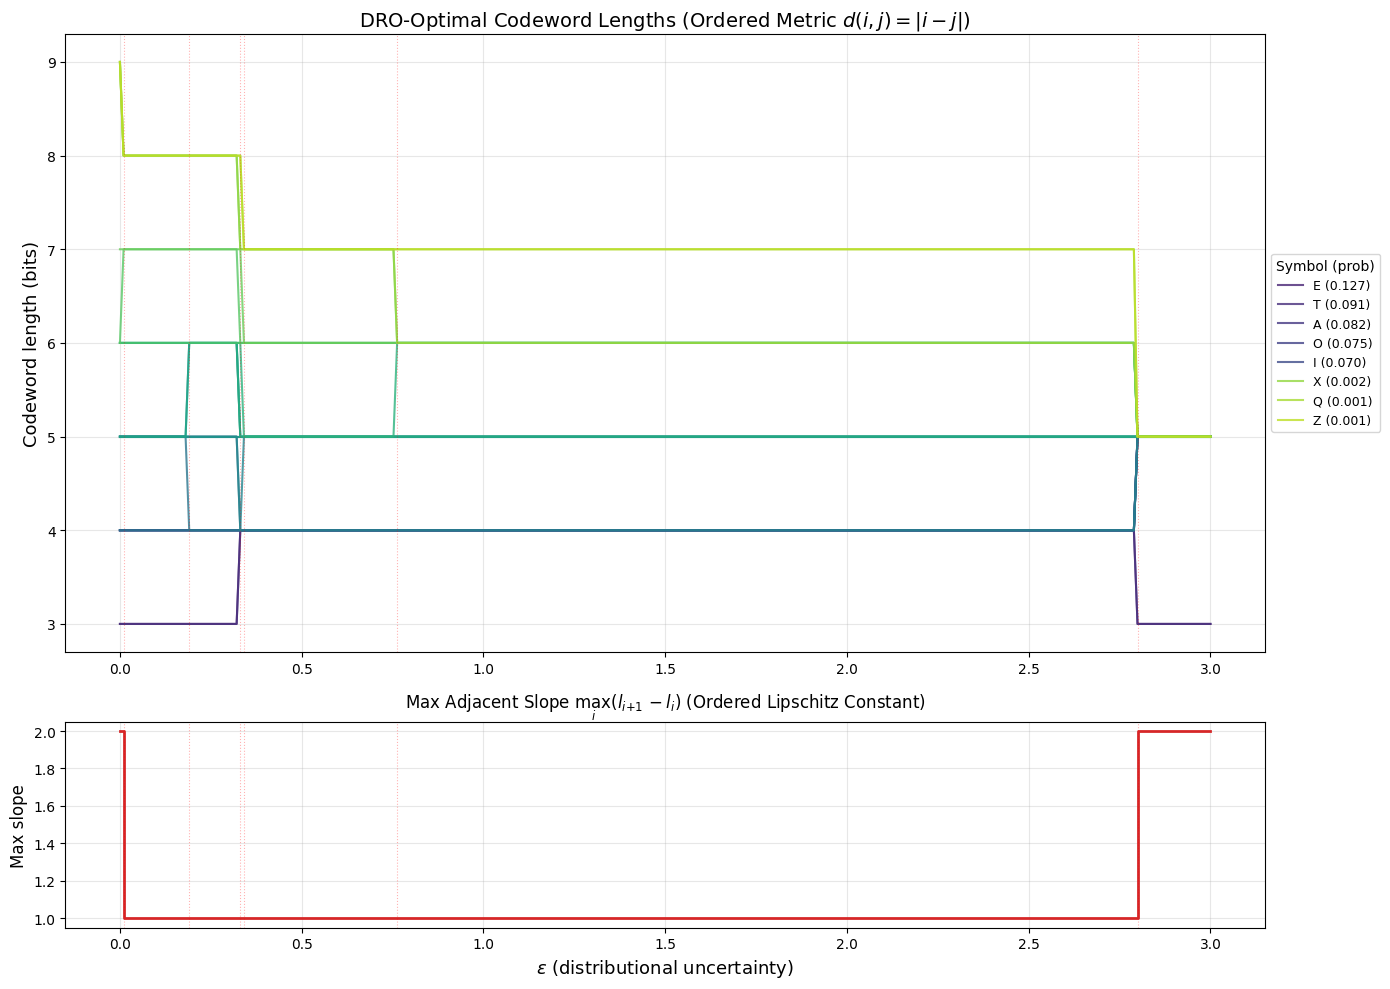

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Top: codeword lengths per symbol
ax = axes[0]
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, n))

for i in range(n):
    label = f"{symbols[i]} ({probs[i]:.3f})" if i < 5 or i >= n - 3 else None
    ax.plot(epsilons, optimal_lengths_array[:, i],
            color=cmap[i], linewidth=1.5, alpha=0.8, label=label)

ax.set_ylabel('Codeword length (bits)', fontsize=13)
ax.set_title('DRO-Optimal Codeword Lengths (Ordered Metric $d(i,j)=|i-j|$)', fontsize=14)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9, title='Symbol (prob)')
ax.grid(True, alpha=0.3)

for eps_start, _ in transitions[1:]:
    ax.axvline(x=eps_start, color='red', linestyle=':', alpha=0.3, linewidth=0.8)

# Bottom: max adjacent slope (ordered Lipschitz constant)
ax2 = axes[1]
slopes_plot = [max_adjacent_slope(c) for c in optimal_codes]
ax2.step(epsilons, slopes_plot, linewidth=2, color='C3', where='post')
ax2.set_xlabel(r'$\varepsilon$ (distributional uncertainty)', fontsize=13)
ax2.set_ylabel('Max slope', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_title(r'Max Adjacent Slope $\max_i(l_{i+1} - l_i)$ (Ordered Lipschitz Constant)', fontsize=12)

for eps_start, _ in transitions[1:]:
    ax2.axvline(x=eps_start, color='red', linestyle=':', alpha=0.3, linewidth=0.8)

plt.tight_layout()
plt.show()

## 9. Length profiles at selected $\varepsilon$ values

Bar charts showing the codeword length assigned to each rank, illustrating
how the ordered metric produces smooth gradients rather than abrupt boundaries.

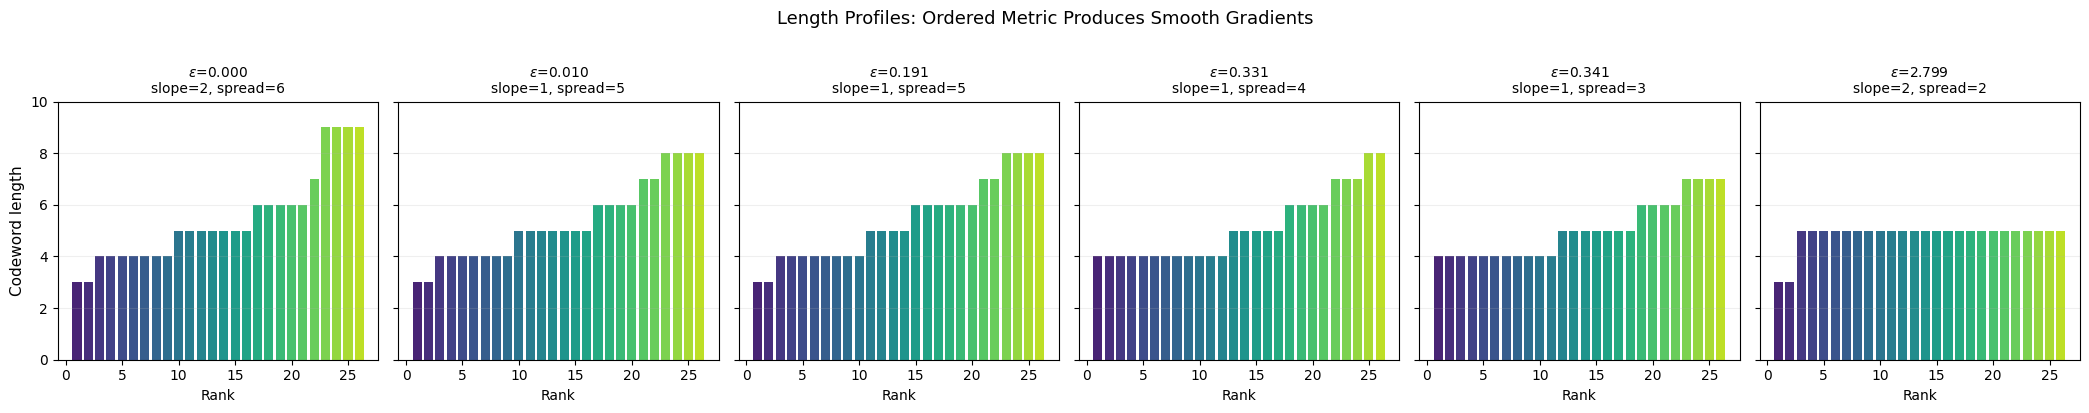

In [10]:
n_panels = min(len(transitions), 6)
panel_indices = np.linspace(0, len(transitions) - 1, n_panels, dtype=int)

fig, axes = plt.subplots(1, n_panels, figsize=(3.5 * n_panels, 4), sharey=True)
if n_panels == 1:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0.1, 0.9, n))

for ax_idx, ti in enumerate(panel_indices):
    eps_start, code = transitions[ti]
    ax = axes[ax_idx]
    ax.bar(range(1, n + 1), code, color=colors, width=0.8)
    ax.set_xlabel('Rank', fontsize=10)
    if ax_idx == 0:
        ax.set_ylabel('Codeword length', fontsize=11)
    slope = max_adjacent_slope(code)
    spread = int(max(code) - min(code))
    ax.set_title(f'$\\varepsilon$={eps_start:.3f}\nslope={slope}, spread={spread}', fontsize=10)
    ax.set_ylim(0, max(huff_lengths) + 1)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Length Profiles: Ordered Metric Produces Smooth Gradients', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Worst-case risk comparison

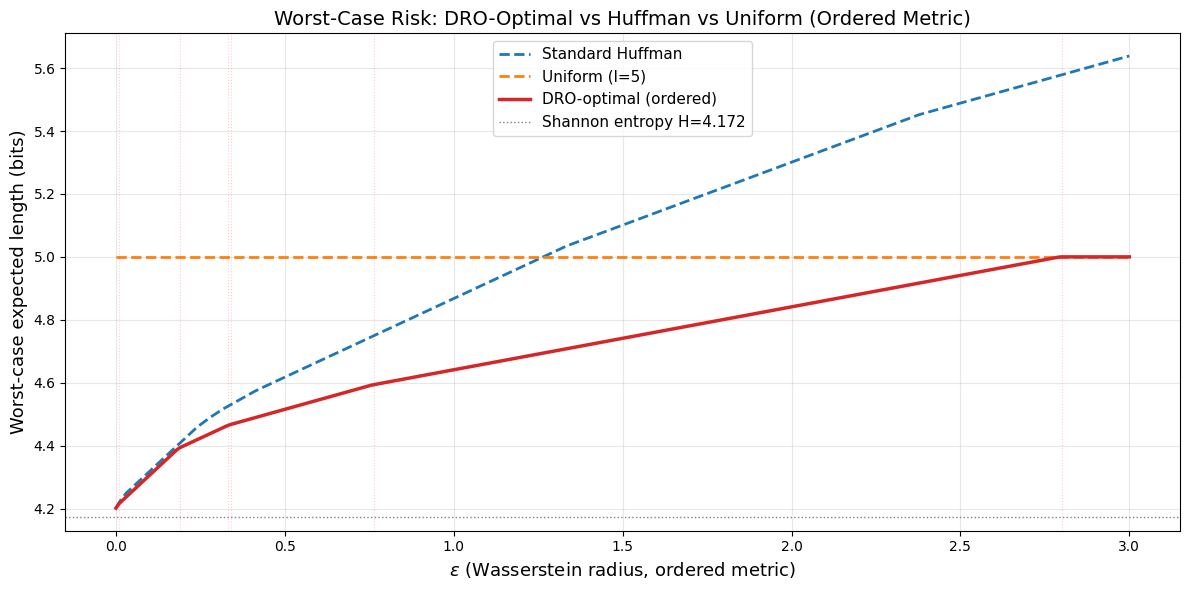

In [11]:
uniform_length = int(np.ceil(np.log2(n)))
uniform_lengths = np.full(n, uniform_length)
uniform_risks = np.array([
    dro_worst_case_risk_ordered(uniform_lengths, probs, eps, n_lambda=100)
    for eps in epsilons
])

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(epsilons, huffman_risks, '--', label='Standard Huffman', linewidth=2, color='C0')
ax.plot(epsilons, uniform_risks, '--', label=f'Uniform (l={uniform_length})', linewidth=2, color='C1')
ax.plot(epsilons, optimal_risks, '-', label='DRO-optimal (ordered)', linewidth=2.5, color='C3')
ax.axhline(y=H, color='gray', linestyle=':', label=f'Shannon entropy H={H:.3f}', linewidth=1)

for eps_start, _ in transitions[1:]:
    ax.axvline(x=eps_start, color='red', linestyle=':', alpha=0.2, linewidth=0.8)

ax.set_xlabel(r'$\varepsilon$ (Wasserstein radius, ordered metric)', fontsize=13)
ax.set_ylabel('Worst-case expected length (bits)', fontsize=13)
ax.set_title('Worst-Case Risk: DRO-Optimal vs Huffman vs Uniform (Ordered Metric)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Comparison with trivial metric

The trivial metric $d = \mathbf{1}_{i \neq j}$ penalizes **spread** $l_{\max} - l_{\min}$.
The ordered metric $d = |i - j|$ penalizes **max slope** $\max_i(l_{i+1} - l_i)$.

Since $\varepsilon$ means different things under each metric, we compare through
**statistical calibration**: for a given sample size $N$, what code does each metric recommend?

In [12]:
# Precompute trivial metric inflated_sums
print("Precomputing trivial metric...")
l_max_vec = all_lengths[:, -1]
mask = all_lengths < l_max_vec[:, None]
masked_lengths = np.where(mask, all_lengths, -np.inf)
second_max = masked_lengths.max(axis=1)
all_equal = ~mask.any(axis=1)
second_max[all_equal] = l_max_vec[all_equal]
M_triv = np.where(all_lengths < l_max_vec[:, None], l_max_vec[:, None], second_max[:, None])

max_gap = int((l_max_vec - all_lengths[:, 0]).max())
lambda_triv = np.arange(0, max_gap + 1, dtype=np.float32)
inflated_triv = np.empty((N_codes, len(lambda_triv)), dtype=np.float32)
for li, lam in enumerate(lambda_triv):
    inflated = np.maximum(all_lengths, M_triv - lam)
    inflated_triv[:, li] = (inflated * probs_f32[None, :]).sum(axis=1)
print(f"Done: {inflated_triv.shape}")


def epsilon_from_samples_tv(N, delta=0.05):
    """Bretagnolle-Huber bound for TV distance (trivial metric W1)."""
    return np.sqrt(np.log(2.0 / delta) / (2 * N))


def epsilon_from_samples_ord(N, n_symbols, delta=0.05):
    """DKW-based bound for ordered metric W1: eps = (n-1) * sqrt(ln(2/delta)/(2N))."""
    return (n_symbols - 1) * np.sqrt(np.log(2.0 / delta) / (2 * N))


def find_optimal_code_triv(eps):
    risk_per_lambda = inflated_triv + lambda_triv[None, :] * eps
    min_risk_per_code = risk_per_lambda.min(axis=1)
    best_idx = int(min_risk_per_code.argmin())
    return feasible_codes[best_idx], float(min_risk_per_code[best_idx])


def find_optimal_code_ord(eps):
    risk_per_lambda = inflated_sums + lambda_candidates[None, :] * eps
    min_risk_per_code = risk_per_lambda.min(axis=1)
    best_idx = int(min_risk_per_code.argmin())
    return feasible_codes[best_idx], float(min_risk_per_code[best_idx])


# Compare at various sample sizes
sample_sizes = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]
delta = 0.05

print(f"\nComparison: Trivial vs Ordered metric (confidence = {1-delta:.0%})\n")
print(f"{'N':>6} | {'--- Trivial metric ---':^36} | {'--- Ordered metric ---':^36}")
print(f"{'':>6} | {'eps_tv':>7} {'spread':>6} {'slope':>5} {'E[L]':>6} {'WC':>7} | "
      f"{'eps_ord':>7} {'spread':>6} {'slope':>5} {'E[L]':>6} {'WC':>7}")
print("-" * 93)

for N in sample_sizes:
    eps_tv = epsilon_from_samples_tv(N, delta)
    eps_ord = epsilon_from_samples_ord(N, n, delta)

    code_tv, risk_tv = find_optimal_code_triv(eps_tv)
    code_ord, risk_ord = find_optimal_code_ord(eps_ord)

    sp_tv = int(max(code_tv) - min(code_tv))
    sl_tv = max_adjacent_slope(code_tv)
    el_tv = float(probs @ code_tv)

    sp_ord = int(max(code_ord) - min(code_ord))
    sl_ord = max_adjacent_slope(code_ord)
    el_ord = float(probs @ code_ord)

    print(f"{N:>6} | {eps_tv:>7.4f} {sp_tv:>6} {sl_tv:>5} {el_tv:>6.3f} {risk_tv:>7.3f} | "
          f"{eps_ord:>7.4f} {sp_ord:>6} {sl_ord:>5} {el_ord:>6.3f} {risk_ord:>7.3f}")

Precomputing trivial metric...
Done: (644928, 9)

Comparison: Trivial vs Ordered metric (confidence = 95%)

     N |        --- Trivial metric ---        |        --- Ordered metric ---       
       |  eps_tv spread slope   E[L]      WC | eps_ord spread slope   E[L]      WC
---------------------------------------------------------------------------------------------
    10 |  0.4295      1     1  4.487   4.917 | 10.7367      2     2  4.564   5.000
    25 |  0.2716      1     1  4.487   4.759 |  6.7905      2     2  4.564   5.000
    50 |  0.1921      1     1  4.487   4.680 |  4.8016      2     2  4.564   5.000
   100 |  0.1358      2     1  4.315   4.586 |  3.3953      2     2  4.564   5.000
   250 |  0.0859      2     1  4.315   4.486 |  2.1473      3     1  4.296   4.871
   500 |  0.0607      2     1  4.315   4.436 |  1.5184      3     1  4.296   4.745
  1000 |  0.0429      4     1  4.224   4.396 |  1.0737      3     1  4.296   4.656
  2500 |  0.0272      4     1  4.224   4.333 |  0

## 12. Lipschitz analysis: slope vs spread

| Metric | Lipschitz constant | DRO penalizes |
|---|---|---|
| Trivial: $d = \mathbf{1}_{i \neq j}$ | $l_{\max} - l_{\min}$ | total spread |
| Ordered: $d = |i - j|$ | $\max_i(l_{i+1} - l_i)$ | sharpest jump |

A code with spread 4 but a smooth gradient (e.g., lengths increasing by 1 every ~6 ranks)
has ordered Lipschitz constant $\approx 1$ — the ordered DRO finds it acceptable.
The trivial DRO would penalize it just as harshly as a code that jumps 4 in one step.

In [13]:
# Show Lipschitz comparison for each transition code
print(f"{'eps':>8} | {'Trivial Lip':>11} {'(spread)':>10} | {'Ordered Lip':>11} {'(max slope)':>12}")
print("-" * 60)

for eps_start, code in transitions:
    spread = int(max(code) - min(code))
    lip_ord = full_lipschitz(code)
    print(f"{eps_start:>8.4f} | {spread:>11} {'':>10} | {lip_ord:>11.2f} {'':>12}")

# Lipschitz upper bound comparison
print("\n--- Lipschitz upper bound: R_eps <= E[L] + eps * Lip ---")
print("\nHuffman code:")
print(f"  Trivial metric bound: R <= {huff_expected:.3f} + {huff_spread} * eps")
print(f"  Ordered metric bound: R <= {huff_expected:.3f} + {huff_lip_ord:.2f} * eps")
print(f"\nAt eps=1.0:")
print(f"  Trivial bound: {huff_expected + huff_spread:.3f}")
print(f"  Ordered bound: {huff_expected + huff_lip_ord:.3f}")

     eps | Trivial Lip   (spread) | Ordered Lip  (max slope)
------------------------------------------------------------
  0.0000 |           6            |        2.00             
  0.0100 |           5            |        1.00             
  0.1906 |           5            |        1.00             
  0.3311 |           4            |        1.00             
  0.3411 |           3            |        1.00             
  0.7625 |           3            |        1.00             
  2.7993 |           2            |        2.00             

--- Lipschitz upper bound: R_eps <= E[L] + eps * Lip ---

Huffman code:
  Trivial metric bound: R <= 4.201 + 6 * eps
  Ordered metric bound: R <= 4.201 + 2.00 * eps

At eps=1.0:
  Trivial bound: 10.201
  Ordered bound: 6.201


## 13. Statistical calibration (ordered metric)

For the ordered metric, the calibration uses the DKW inequality on the CDF:

$$W_1^{\text{ord}}(\hat{P}_N, P) = \sum_{k=1}^{n-1} |\hat{F}_N(k) - F(k)| \leq (n-1) \sup_k |\hat{F}_N(k) - F(k)|$$

By DKW: $\mathbb{P}(\sup_k |\hat{F}_N(k) - F(k)| > t) \leq 2e^{-2Nt^2}$

$$\varepsilon_N^{\text{ord}}(\delta) = (n-1)\sqrt{\frac{\ln(2/\delta)}{2N}}$$

This is $(n-1) = 25$ times larger than the trivial-metric bound, reflecting
that the ordered $W_1$ uses a richer metric.

In [14]:
sample_sizes_cal = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]
delta = 0.05

print(f"Statistical calibration - ordered metric (confidence = {1-delta:.0%})")
print(f"eps_N = (n-1) * sqrt(ln(2/delta) / (2N)) = 25 * sqrt(ln(40) / (2N))\n")
print(f"{'N':>8} {'eps':>8} {'spread':>7} {'slope':>6} {'lmin':>5} {'lmax':>5} {'E[L]':>7} {'WC risk':>8}  profile")
print("-" * 90)

for N in sample_sizes_cal:
    eps = epsilon_from_samples_ord(N, n, delta)
    code, risk = find_optimal_code_ord(eps)

    spread = int(max(code) - min(code))
    slope = max_adjacent_slope(code)
    unique, counts = np.unique(code, return_counts=True)
    prof_str = ', '.join(f'{c}x{l}b' for l, c in zip(unique, counts))
    print(f"{N:>8} {eps:>8.3f} {spread:>7} {slope:>6} {int(min(code)):>5} {int(max(code)):>5} "
          f"{float(probs @ code):>7.3f} {risk:>8.3f}  {prof_str}")

Statistical calibration - ordered metric (confidence = 95%)
eps_N = (n-1) * sqrt(ln(2/delta) / (2N)) = 25 * sqrt(ln(40) / (2N))

       N      eps  spread  slope  lmin  lmax    E[L]  WC risk  profile
------------------------------------------------------------------------------------------
      10   10.737       2      2     3     5   4.564    5.000  2x3b, 24x5b
      25    6.791       2      2     3     5   4.564    5.000  2x3b, 24x5b
      50    4.802       2      2     3     5   4.564    5.000  2x3b, 24x5b
     100    3.395       2      2     3     5   4.564    5.000  2x3b, 24x5b
     250    2.147       3      1     4     7   4.296    4.871  11x4b, 6x5b, 7x6b, 2x7b
     500    1.518       3      1     4     7   4.296    4.745  11x4b, 6x5b, 7x6b, 2x7b
    1000    1.074       3      1     4     7   4.296    4.656  11x4b, 6x5b, 7x6b, 2x7b
    2500    0.679       3      1     4     7   4.279    4.569  11x4b, 7x5b, 4x6b, 4x7b
    5000    0.480       3      1     4     7   4.279    4.509

## 14. Convergence to Huffman as $N$ grows

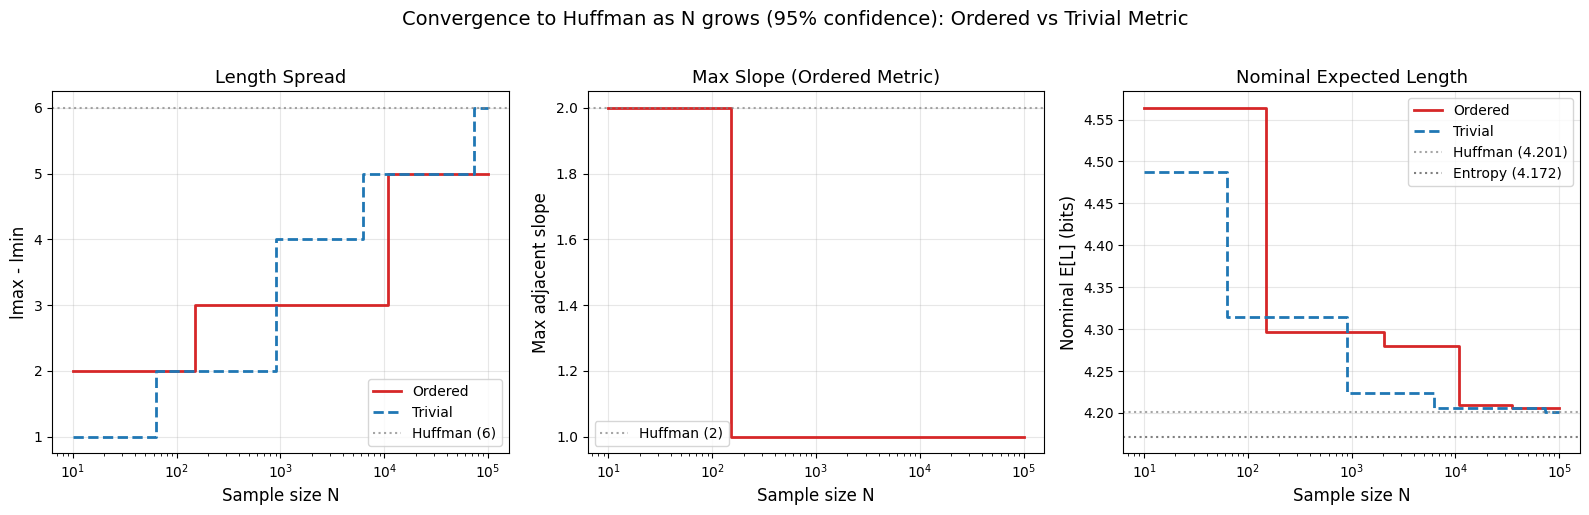

In [15]:
N_range = np.unique(np.logspace(1, 5, 150).astype(int))

spreads_ord = []
slopes_ord = []
nom_lens_ord = []

for N in N_range:
    eps = epsilon_from_samples_ord(N, n, delta=0.05)
    code, _ = find_optimal_code_ord(eps)
    spreads_ord.append(int(max(code) - min(code)))
    slopes_ord.append(max_adjacent_slope(code))
    nom_lens_ord.append(float(probs @ code))

# Also compute trivial metric convergence for comparison
spreads_triv = []
nom_lens_triv = []

for N in N_range:
    eps = epsilon_from_samples_tv(N, delta=0.05)
    code, _ = find_optimal_code_triv(eps)
    spreads_triv.append(int(max(code) - min(code)))
    nom_lens_triv.append(float(probs @ code))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Spread
axes[0].step(N_range, spreads_ord, linewidth=2, color='C3', where='post', label='Ordered')
axes[0].step(N_range, spreads_triv, linewidth=2, color='C0', where='post', label='Trivial', linestyle='--')
axes[0].axhline(y=max(huff_lengths) - min(huff_lengths), color='gray', linestyle=':',
                label=f'Huffman ({max(huff_lengths)-min(huff_lengths)})', alpha=0.7)
axes[0].set_xlabel('Sample size N', fontsize=12)
axes[0].set_ylabel('lmax - lmin', fontsize=12)
axes[0].set_title('Length Spread', fontsize=13)
axes[0].set_xscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Max slope (ordered metric specific)
axes[1].step(N_range, slopes_ord, linewidth=2, color='C3', where='post')
axes[1].axhline(y=huff_max_slope, color='gray', linestyle=':',
                label=f'Huffman ({huff_max_slope})', alpha=0.7)
axes[1].set_xlabel('Sample size N', fontsize=12)
axes[1].set_ylabel('Max adjacent slope', fontsize=12)
axes[1].set_title('Max Slope (Ordered Metric)', fontsize=13)
axes[1].set_xscale('log')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Nominal expected length
axes[2].step(N_range, nom_lens_ord, linewidth=2, color='C3', label='Ordered', where='post')
axes[2].step(N_range, nom_lens_triv, linewidth=2, color='C0', label='Trivial', where='post', linestyle='--')
axes[2].axhline(y=huff_expected, color='gray', linestyle=':',
                label=f'Huffman ({huff_expected:.3f})', alpha=0.7)
axes[2].axhline(y=H, color='black', linestyle=':', label=f'Entropy ({H:.3f})', alpha=0.5)
axes[2].set_xlabel('Sample size N', fontsize=12)
axes[2].set_ylabel('Nominal E[L] (bits)', fontsize=12)
axes[2].set_title('Nominal Expected Length', fontsize=13)
axes[2].set_xscale('log')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Convergence to Huffman as N grows (95% confidence): Ordered vs Trivial Metric',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()